In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("data/DSU-Dataset.csv")

df['Date'] = pd.to_datetime(df['Date'])
df.drop('REASON_VISIT_NAME', axis=1, inplace=True)
df['Hour'] = df['Hour'] // 6
df['Hour'] = df['Hour'].astype('int')
df = df.groupby(['Site', 'Date', 'Hour'])[['ED Enc', 'ED Enc Admitted']].sum().reset_index()
df.head()

,Site,Date,Hour,ED Enc,ED Enc Admitted
0,A,2018-01-01,0,16,6
1,A,2018-01-01,1,25,8
2,A,2018-01-01,2,52,16
3,A,2018-01-01,3,36,10
4,A,2018-01-02,0,18,5


In [29]:
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['DOW'] = df['Date'].dt.day_of_week
df['Days In Month'] = df['Date'].dt.daysinmonth
df['Week of Month'] = df['Date'].dt.day // 7
df['month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

df.head()

,Site,Date,Hour,ED Enc,ED Enc Admitted,Month,Year,DOW,Days In Month,Week of Month,month_sin,month_cos
0,A,2018-01-01,0,16,6,1,2018,0,31,0,0.5,0.866025
1,A,2018-01-01,1,25,8,1,2018,0,31,0,0.5,0.866025
2,A,2018-01-01,2,52,16,1,2018,0,31,0,0.5,0.866025
3,A,2018-01-01,3,36,10,1,2018,0,31,0,0.5,0.866025
4,A,2018-01-02,0,18,5,1,2018,1,31,0,0.5,0.866025


In [30]:
df_ed = pd.read_csv('ed_preds.csv')

df_ed['Date'] = pd.to_datetime(df_ed['Date'])
train_cutoff = df_ed['Date'].min()

print(f"The earliest date in the dataset is: {train_cutoff}")

The earliest date in the dataset is: 2025-08-01 00:00:00


In [31]:
df['Datetime'] = pd.to_datetime(
    dict(year=df['Year'], month=df['Month'], day=1)
) + pd.to_timedelta(df['Hour'], unit='h')
df['Datetime'] = pd.to_datetime(df['Date']) + pd.to_timedelta(df['Hour'], unit='h')

train = df[df['Datetime'] < train_cutoff].copy()
test  = df[df['Datetime'] >= train_cutoff].copy()
# valid = df[df['Datetime'] > valid_cutoff].copy()

train.drop(['Date', 'Datetime'], axis=1, inplace=True)
# valid.drop(['Date', 'Datetime'], axis=1, inplace=True)
X_test_datetime = test['Datetime']

In [32]:
X_train = train.drop('ED Enc Admitted', axis=1)
y_train = train['ED Enc Admitted']

# X_valid = valid.drop('ED Enc Ratio', axis=1)
# y_valid = valid['ED Enc Ratio']

X_test = test.drop(['ED Enc Admitted', 'ED Enc'], axis=1)
y_test = test['ED Enc Admitted']

In [33]:
X_test = pd.merge(
    X_test, 
    df_ed[['Site', 'Date', 'Hour', 'ED Enc']], 
    on=['Site', 'Date', 'Hour'], 
    how='left'
)

X_test.drop(['Date', 'Datetime'], axis=1, inplace=True) # Drop true values of ED Enc. We want our predicted vals
X_test = X_test[X_train.columns]
X_test.head()


,Site,Hour,ED Enc,Month,Year,DOW,Days In Month,Week of Month,month_sin,month_cos
0,A,0,17.239264,8,2025,4,31,0,-0.866025,-0.5
1,A,1,33.685584,8,2025,4,31,0,-0.866025,-0.5
2,A,2,49.400466,8,2025,4,31,0,-0.866025,-0.5
3,A,3,35.380038,8,2025,4,31,0,-0.866025,-0.5
4,A,0,14.037630,8,2025,5,31,0,-0.866025,-0.5


In [34]:
from catboost import CatBoostRegressor

cat_features = ['Site', 'Hour', 'Month', 'DOW', 'Week of Month']

model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Quantile:alpha=0.6',
    eval_metric='MAE',
    random_seed=42,
    verbose=100
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    use_best_model=True
)


0:	learn: 4.0412625	test: 4.4081644	best: 4.4081644 (0)	total: 287ms	remaining: 2m 23s
100:	learn: 1.9430329	test: 2.0449539	best: 2.0447852 (99)	total: 15.9s	remaining: 1m 2s
200:	learn: 1.9187638	test: 2.0364101	best: 2.0348957 (142)	total: 30.5s	remaining: 45.3s
300:	learn: 1.9077775	test: 2.0420476	best: 2.0348957 (142)	total: 47.1s	remaining: 31.1s
400:	learn: 1.8997728	test: 2.0440995	best: 2.0348957 (142)	total: 1m 2s	remaining: 15.4s
499:	learn: 1.8956965	test: 2.0414720	best: 2.0348957 (142)	total: 1m 16s	remaining: 0us

bestTest = 2.034895719
bestIteration = 142

Shrink model to first 143 iterations.


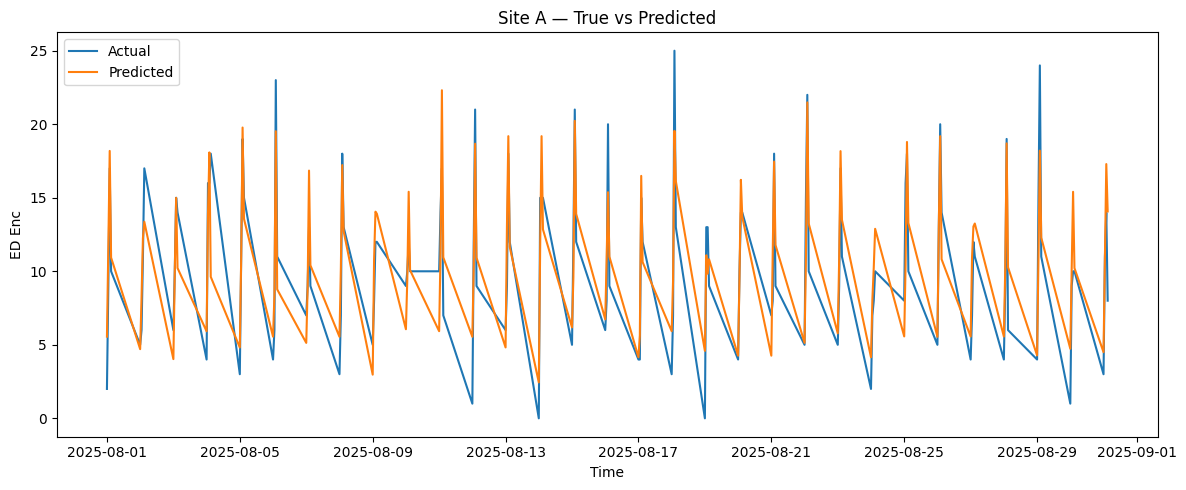

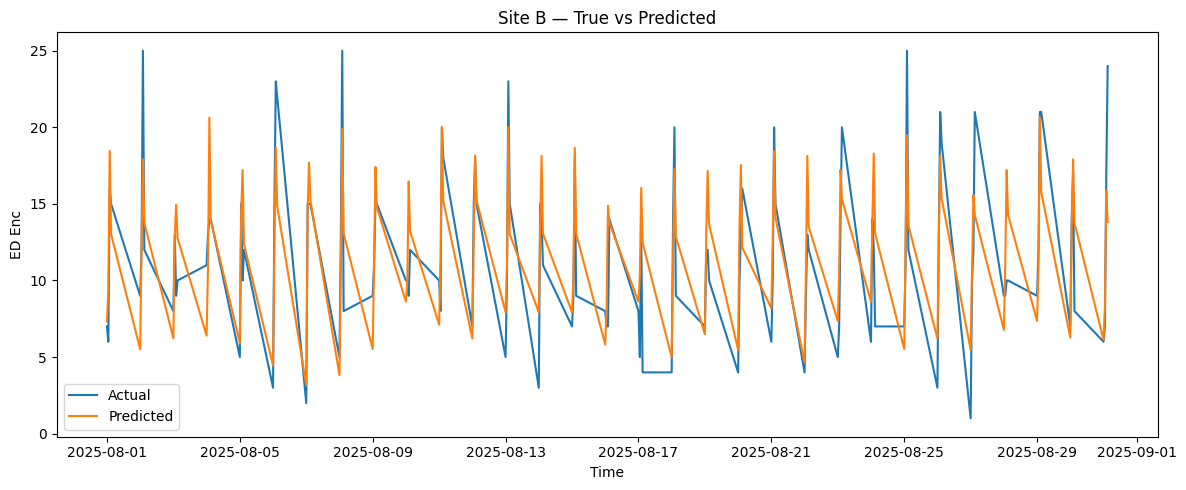

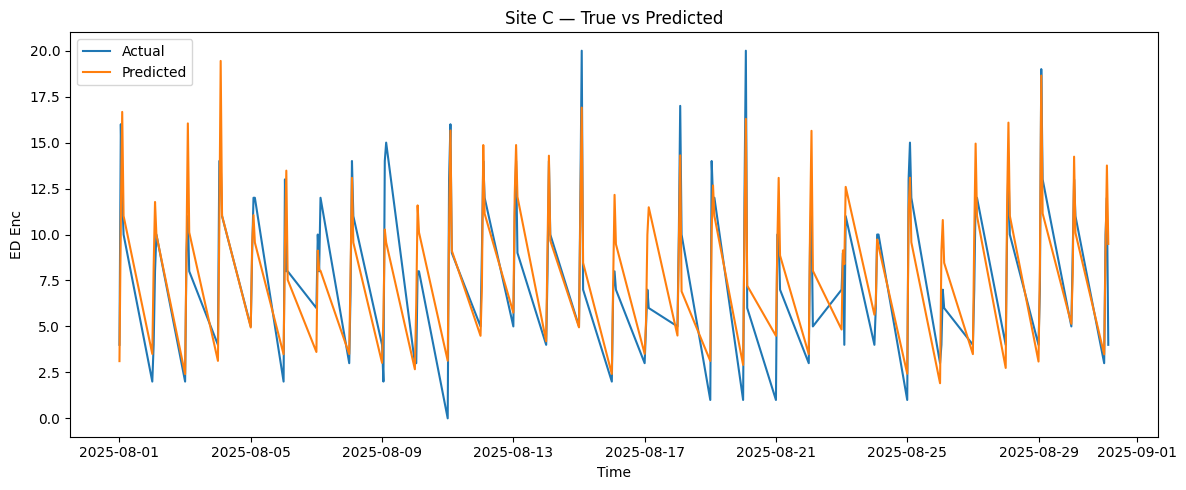

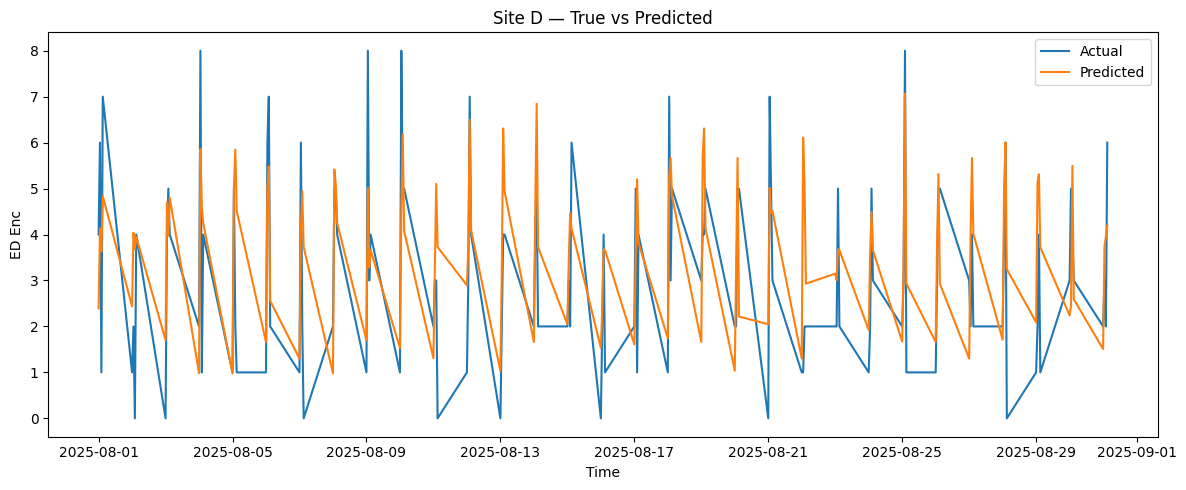

In [51]:
y_pred = model.predict(X_test)

plot_df = X_test.copy()
plot_df["Datetime"] = X_test_datetime.values
plot_df['y_true'] = y_test.values
plot_df['y_pred'] = y_pred
plot_df = plot_df.sort_values(['Site', 'Datetime'])
import matplotlib.pyplot as plt

sites = plot_df['Site'].unique()

for site in sites:
    site_df = plot_df[plot_df['Site'] == site]

    plt.figure(figsize=(12, 5))
    plt.plot(site_df['Datetime'], site_df['y_true'])
    plt.plot(site_df['Datetime'], site_df['y_pred'])

    plt.title(f'Site {site} — True vs Predicted')
    plt.xlabel('Time')
    plt.ylabel('ED Enc')
    plt.legend(['Actual', 'Predicted'])
    plt.tight_layout()
    plt.show()


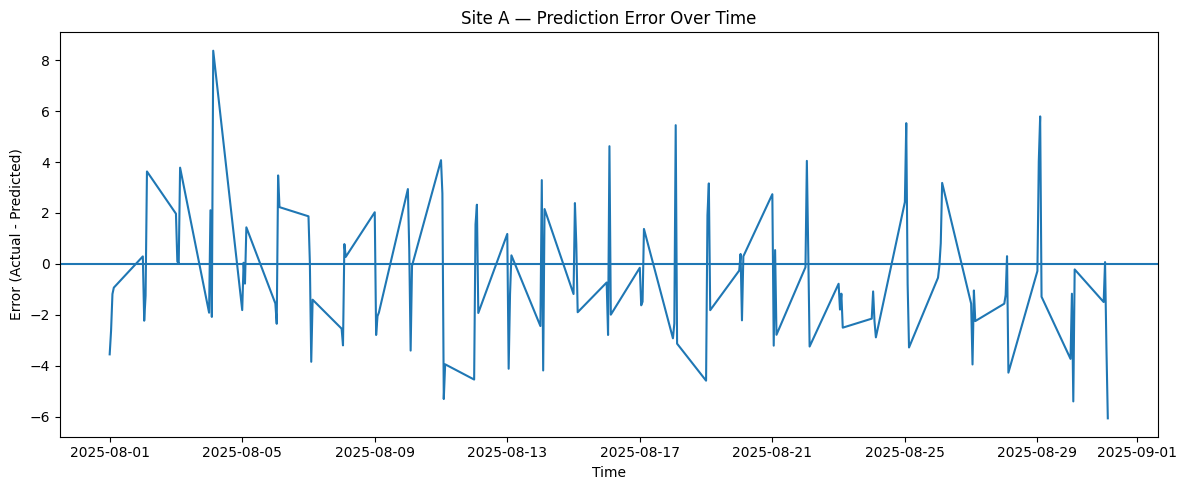

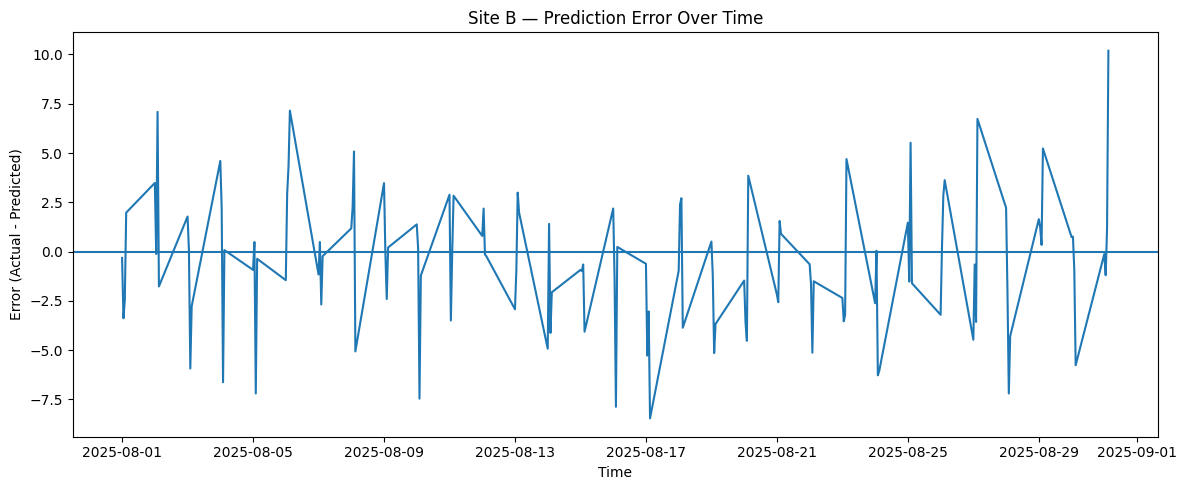

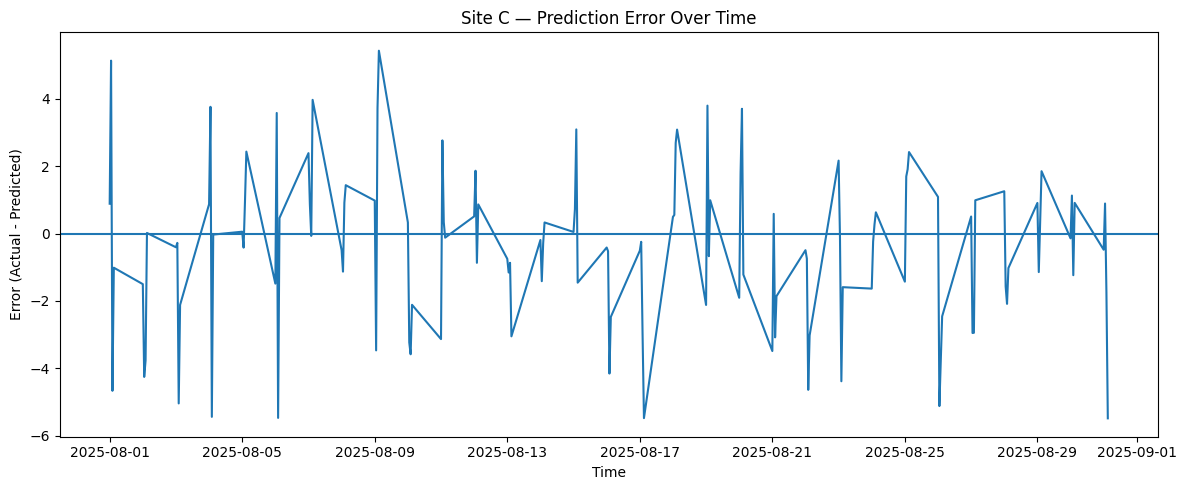

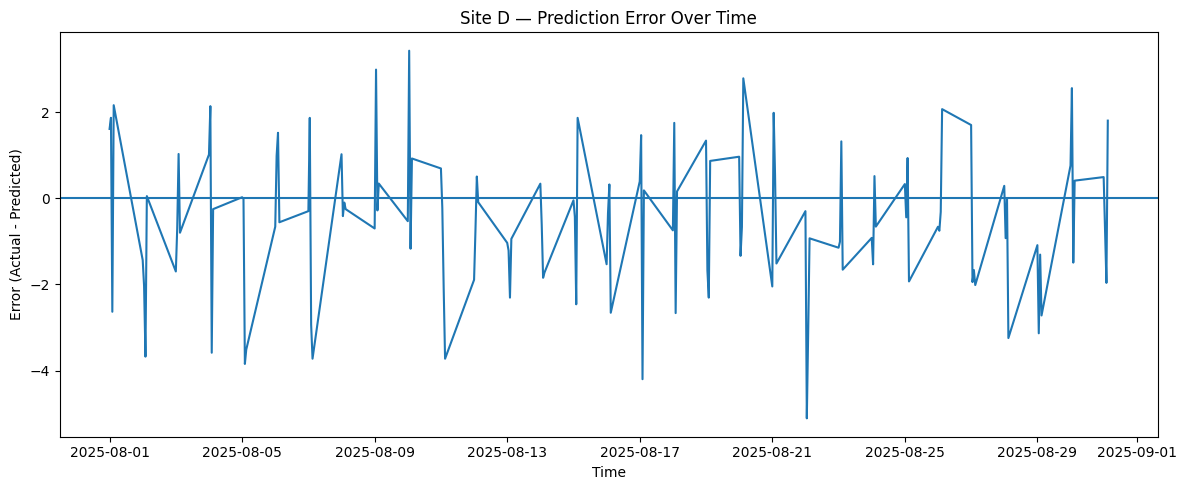

In [52]:
plot_df['error'] = plot_df['y_true'] - plot_df['y_pred']
plot_df['abs_error'] = plot_df['error'].abs()
for site in sites:
    site_df = plot_df[plot_df['Site'] == site]

    plt.figure(figsize=(12, 5))
    plt.plot(site_df['Datetime'], site_df['error'])
    plt.axhline(0)  # zero baseline

    plt.title(f'Site {site} — Prediction Error Over Time')
    plt.xlabel('Time')
    plt.ylabel('Error (Actual - Predicted)')
    plt.tight_layout()
    plt.show()


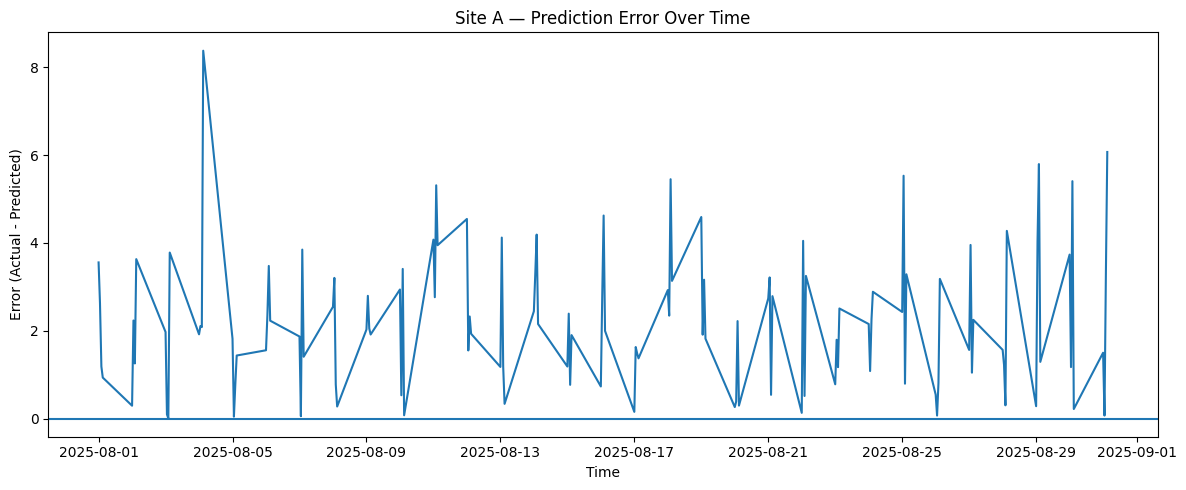

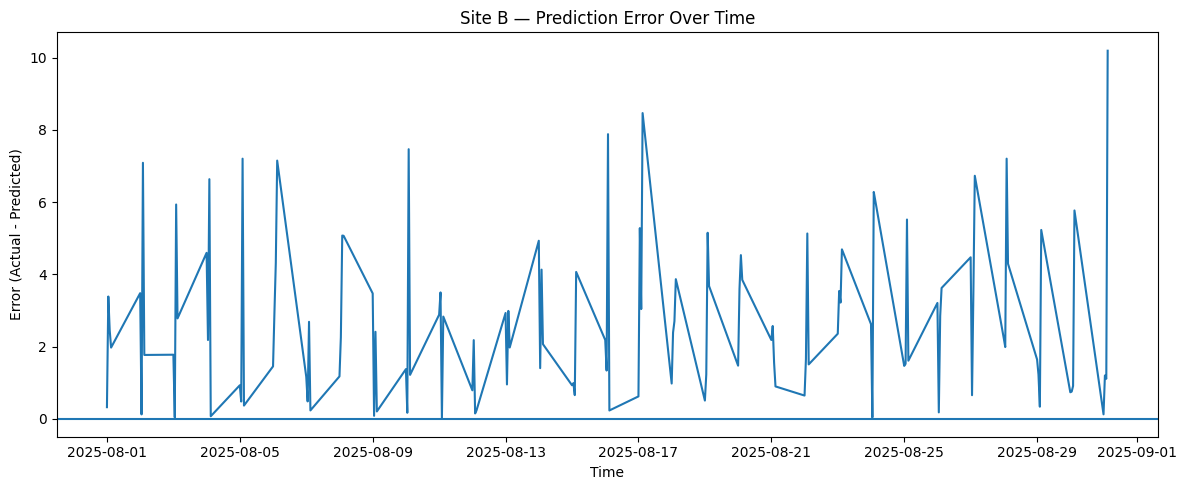

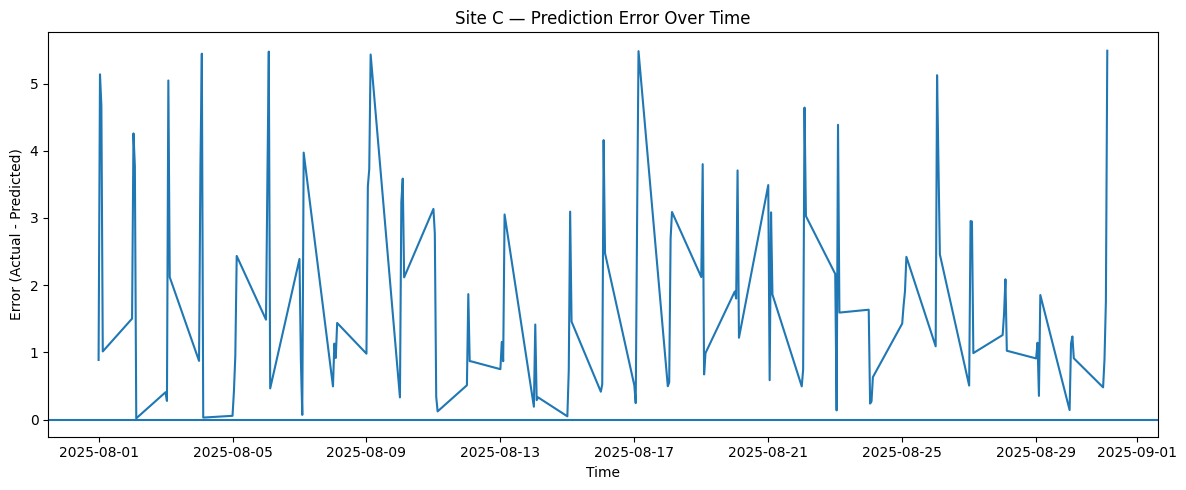

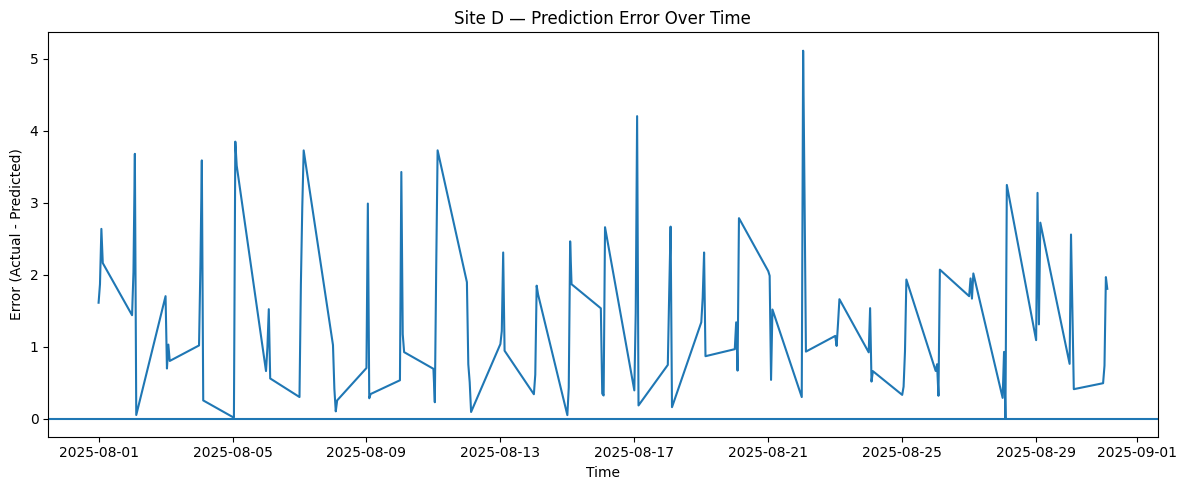

In [53]:
for site in sites:
    site_df = plot_df[plot_df['Site'] == site]

    plt.figure(figsize=(12, 5))
    plt.plot(site_df['Datetime'], site_df['abs_error'])
    plt.axhline(0)  # zero baseline

    plt.title(f'Site {site} — Prediction Error Over Time')
    plt.xlabel('Time')
    plt.ylabel('Error (Actual - Predicted)')
    plt.tight_layout()
    plt.show()

In [54]:
importances = model.get_feature_importance()

feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_imp)

         Feature  Importance
2         ED Enc   52.068924
0           Site   24.338336
1           Hour   19.399154
4           Year    2.080611
5            DOW    1.482383
7  Week of Month    0.162738
9      month_cos    0.156950
6  Days In Month    0.143721
8      month_sin    0.139594
3          Month    0.027588
